In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd


NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "statistic" else NOTEBOOK_DIR
TEST_RESULT_ROOT = PROJECT_ROOT / "test_result"

RUNS = [
    {
        "name": "DQN v8.12.1",
        "path": TEST_RESULT_ROOT / "Test_Results_DQN_v8.12.1_variant_0.csv",
        "color": "tab:blue",
    },
    {
        "name": "DQN v8.11.10",
        "path": TEST_RESULT_ROOT / "Test_Results_DQN_v8.11.10_variant_0.csv",
        "color": "tab:orange",
    },
    {
        "name": "DQN v8.9.2",
        "path": TEST_RESULT_ROOT / "Test_Results_DQN_v8.9.2_variant_0.csv",
        "color": "tab:green",
    },
    {
        "name": "DQN v8.5.28",
        "path": TEST_RESULT_ROOT / "Test_Results_DQN_v8.5.28_variant_0.csv",
        "color": "tab:red",
    },
]


def read_test_results(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing test result file: {path}")

    rows = []
    pattern = re.compile(r"Episode\s+(\d+)\s*:\s*([-+]?\d+(?:\.\d+)?)")
    for line in path.read_text().splitlines():
        match = pattern.match(line.strip())
        if match:
            rows.append({
                "test_episode": int(match.group(1)),
                "reward": float(match.group(2)),
            })

    if not rows:
        raise ValueError(f"No episode reward rows found in {path}")

    return pd.DataFrame(rows)


print(f"Project root: {PROJECT_ROOT}")
print(f"Test result root: {TEST_RESULT_ROOT}")


Project root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team
Test result root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team/test_result


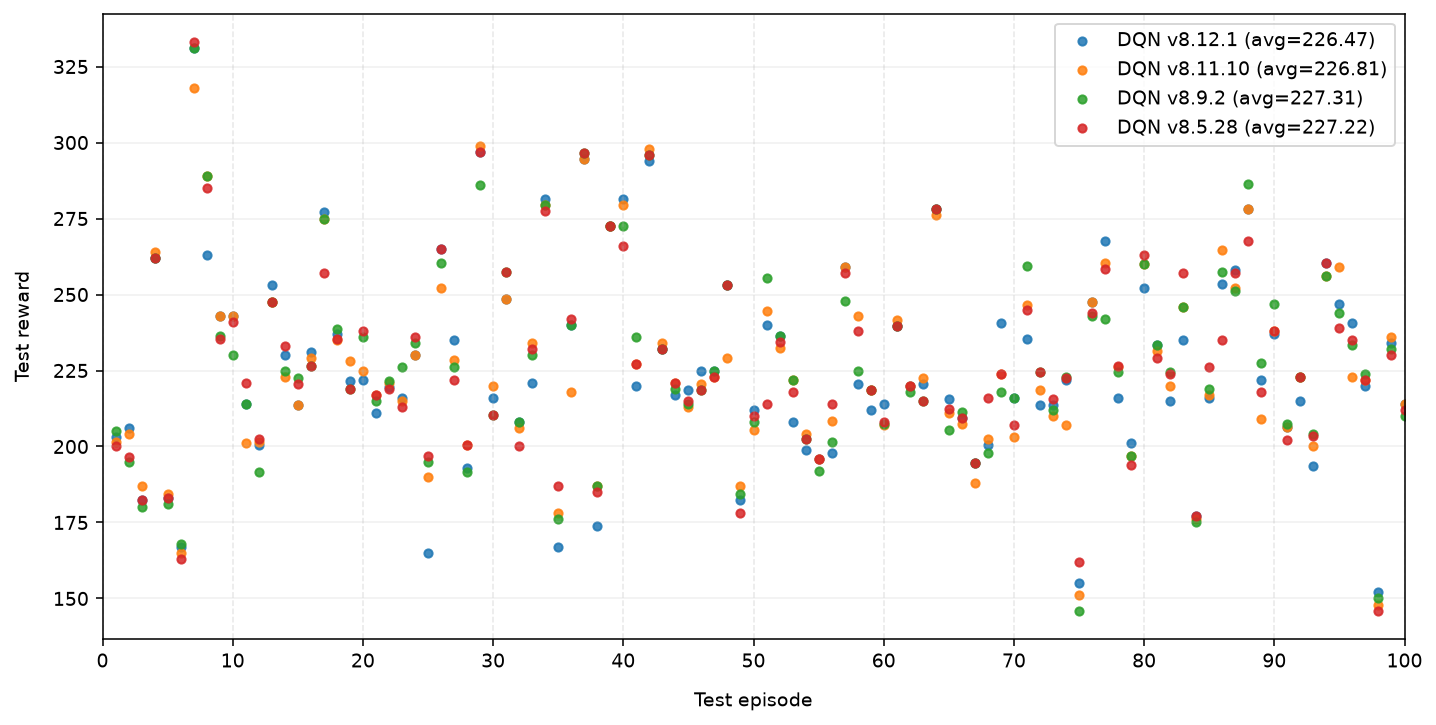

,run,episodes,average_reward,max_reward,min_reward
0,DQN v8.12.1,100,226.470,331.0,152.0
1,DQN v8.11.10,100,226.805,318.0,148.0
2,DQN v8.9.2,100,227.305,331.0,146.0
3,DQN v8.5.28,100,227.220,333.0,146.0


In [6]:
fig, ax = plt.subplots(figsize=(12, 5.8), dpi=140)

summary_rows = []
for run in RUNS:
    df = read_test_results(run["path"])
    ax.scatter(
        df["test_episode"],
        df["reward"],
        label=f"{run['name']} (avg={df['reward'].mean():.2f})",
        color=run["color"],
        s=18,
        alpha=0.85,
    )
    summary_rows.append({
        "run": run["name"],
        "episodes": len(df),
        "average_reward": df["reward"].mean(),
        "max_reward": df["reward"].max(),
        "min_reward": df["reward"].min(),
    })

ax.set_xlabel("Test episode", labelpad=10)
ax.set_ylabel("Test reward", labelpad=10)
ax.set_xlim(1, 100)
ax.set_xticks(range(0, 101, 10))
ax.grid(axis="x", linestyle="--", alpha=0.28)
ax.grid(axis="y", linestyle="-", alpha=0.18)
ax.legend(loc="upper right", frameon=True)

plt.show()

summary = pd.DataFrame(summary_rows)
summary
